# Эксперементы с датасетом №1

## Набор данных

In [1]:
import kagglehub
import pandas as pd
import os

path1 = kagglehub.dataset_download("ankitverma2010/ecommerce-customer-churn-analysis-and-prediction")
file_path = os.path.join(path1, 'E Commerce Dataset.xlsx')
df = pd.read_excel(file_path, sheet_name='E Comm', usecols='A:T')
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [2]:
dictData = pd.read_excel(file_path, sheet_name='Data Dict', usecols='C:D', skiprows=1)
dictData

,Variable,Discerption
0,CustomerID,Unique customer ID
1,Churn,Churn Flag
2,Tenure,Tenure of customer in organization
3,PreferredLoginDevice,Preferred login device of customer
4,CityTier,City tier
5,WarehouseToHome,Distance in between warehouse to home of customer
6,PreferredPaymentMode,Preferred payment method of customer
7,Gender,Gender of customer
8,HourSpendOnApp,Number of hours spend on mobile application or...
9,NumberOfDeviceRegistered,Total number of deceives is registered on part...


## Предобработка данных

Функция для создания пайплайна предобработки данных

In [3]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.base import BaseEstimator, TransformerMixin

class ValueReplacer(BaseEstimator, TransformerMixin):
    def __init__(self, replacements: dict):
        self.replacements = replacements

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col, mapping in self.replacements.items():
            if col in X.columns:
                X[col] = X[col].replace(mapping)
        return X
    
    def get_feature_names_out(self, input_features=None):
        return input_features

def create_preprocessing_pipeline(X, encoder: str = 'onehot', scale: bool = True):
    cat_columns = X.select_dtypes(include=['object', 'string']).columns.tolist()
    num_columns = X.select_dtypes(include='number').columns.tolist()
    
    for col in ['Churn', 'CustomerID']:
        if col in cat_columns: cat_columns.remove(col)
        if col in num_columns: num_columns.remove(col)

    replacements = {
        'PreferredLoginDevice': {'Mobile Phone': 'Phone'},
        'PreferredPaymentMode': {'Credit Card': 'CC'},
        'PreferedOrderCat': {'Mobile Phone': 'Mobile'}
    }

    num_steps = [('imputer', SimpleImputer(strategy='mean'))]
    if scale:
        num_steps.append(('scaler', StandardScaler()))
    num_pipe = Pipeline(num_steps)

    cat_steps = [('imputer', SimpleImputer(strategy='most_frequent'))]
    if encoder == 'onehot':
        cat_steps.append(('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)))
    elif encoder == 'ordinal':
        cat_steps.append(('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)))
    else:
        raise ValueError("encoder должен быть 'onehot' или 'ordinal'")
    cat_pipe = Pipeline(cat_steps)

    # 🔑 FIX: verbose_feature_names_out=False убирает префиксы num__ и cat__
    preprocessor = ColumnTransformer([
        ('num', num_pipe, num_columns),
        ('cat', cat_pipe, cat_columns)
    ], remainder='drop', verbose_feature_names_out=False)

    pipeline = Pipeline([
        ('replacer', ValueReplacer(replacements)),
        ('preprocessor', preprocessor)
    ])

    # ✅ Автоматический вывод в DataFrame с корректными именами
    pipeline.set_output(transform="pandas")
    return pipeline

In [4]:
df.head(13)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
5,50006,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Mobile Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139.19
6,50007,1,NaN,Phone,3,11.0,Cash on Delivery,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,120.86
7,50008,1,NaN,Phone,1,6.0,CC,Male,3.0,3,Mobile,2,Divorced,3,1,16.0,2.0,2.0,0.0,122.93
8,50009,1,13.0,Phone,3,9.0,E wallet,Male,NaN,4,Mobile,3,Divorced,2,1,14.0,0.0,1.0,2.0,126.83
9,50010,1,NaN,Phone,1,31.0,Debit Card,Male,2.0,5,Mobile,3,Single,2,0,12.0,1.0,1.0,1.0,122.93


Создание и применение пайплайнов

In [5]:
from sklearn.model_selection import train_test_split

# 1. Разделяем данные (пайплайн обучается ТОЛЬКО на X_train)
X = df.drop(columns=['Churn', 'CustomerID'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2. Создаем и настраиваем пайплайн
# Вариант A: One-Hot + Масштабирование
pipe_ohe = create_preprocessing_pipeline(X_train, encoder='onehot', scale=True)
X_train_ohe = pipe_ohe.fit_transform(X_train)
X_test_ohe = pipe_ohe.transform(X_test)

# Вариант B: Ordinal + Без масштабирования
pipe_ord = create_preprocessing_pipeline(X_train, encoder='ordinal', scale=False)
X_train_ord = pipe_ord.fit_transform(X_train)
X_test_ord = pipe_ord.transform(X_test)

# Вариант С: Ordinal + масштабирования
pipe_ord_sc = create_preprocessing_pipeline(X_train, encoder='ordinal', scale=False)
X_train_ord_sc = pipe_ord_sc.fit_transform(X_train)
X_test_ord_sc = pipe_ord_sc.transform(X_test)

# Проверка размеров
print(f"One-Hot shape: {X_train_ohe.shape}")
print(f"Ordinal shape: {X_train_ord.shape}")
print(f"Ordinal shape: {X_train_ord_sc.shape}")

One-Hot shape: (4504, 31)
Ordinal shape: (4504, 18)
Ordinal shape: (4504, 18)


Сохранение пайплайнов для продакшена

## Построение и обучение моделей

### Логистическая регрессия

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'C': np.logspace(-4, 4, 9), 'l1_ratio': [0]},              # Чистый L2
    {'C': np.logspace(-4, 4, 9), 'l1_ratio': [1]},              # Чистый L1
    {'C': np.logspace(-4, 4, 9), 'l1_ratio': [0.2, 0.5, 0.8]},  # ElasticNet
    {'C': [1e6, 1e7, 1e8], 'l1_ratio': [0]}                     # Практически без регуляризации
]

lr_gs = GridSearchCV(
    LogisticRegression(class_weight='balanced', solver='saga'),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

lr_gs.fit(X_train_ohe, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...solver='saga')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': array([1.e-04... 1.e+04]), 'l1_ratio': [0]}, {'C': array([1.e-04... 1.e+04]), 'l1_ratio': [1]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is di

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score
from sklearn.metrics import roc_curve, precision_recall_curve, auc, RocCurveDisplay, PrecisionRecallDisplay

best_lr = lr_gs.best_estimator_
y_pred = best_lr.predict(X_test_ohe)

print(f"Best: {lr_gs.best_params_} | Score: {lr_gs.best_score_:.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Best: {'C': np.float64(0.01), 'l1_ratio': 0} | Score: 0.5900
Accuracy:  0.7806
Precision: 0.4240
Recall:    0.8368
F1-score:  0.5628

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.77      0.85       936
           1       0.42      0.84      0.56       190

    accuracy                           0.78      1126
   macro avg       0.69      0.80      0.71      1126
weighted avg       0.87      0.78      0.80      1126



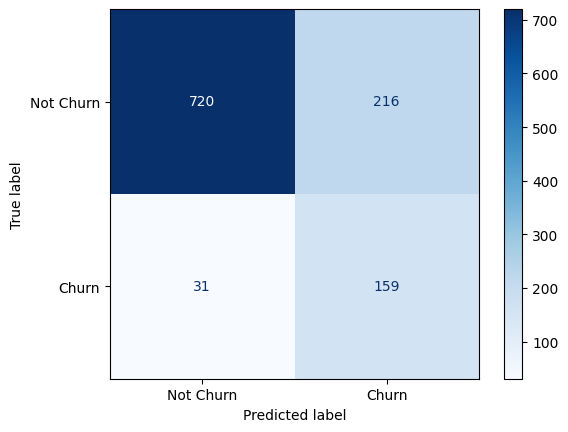

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_lr, X_test_ohe, y_test,
    display_labels=['Not Churn', 'Churn'],
    cmap='Blues',
    values_format='d'
)

### Дерево решений

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Сетка параметров
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20],
    'max_features': range(2, 18, 2),
    'min_samples_leaf': [1, 2, 5, 10, 20]
}

grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_ord, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_features': range(2, 18, 2), 'min_samples_leaf': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : 

In [10]:
best_model_dt = grid_search.best_estimator_
y_pred = best_model_dt.predict(X_test_ord)

acc_dt = accuracy_score(y_test, y_pred)
prec_dt = precision_score(y_test, y_pred)
rec_dt = recall_score(y_test, y_pred)
f1_dt = f1_score(y_test, y_pred)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший score на валидации: {grid_search.best_score_}\n")
print(f"Accuracy: {acc_dt:.4f}")
print(f"Precision: {prec_dt:.4f}")
print(f"Recall: {rec_dt:.4f}")
print(f"F1-score: {f1_dt:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Лучшие параметры: {'max_depth': 20, 'max_features': 10, 'min_samples_leaf': 1}
Лучший score на валидации: 0.7970289463411921

Accuracy: 0.9609
Precision: 0.8687
Recall: 0.9053
F1-score: 0.8866

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98       936
           1       0.87      0.91      0.89       190

    accuracy                           0.96      1126
   macro avg       0.92      0.94      0.93      1126
weighted avg       0.96      0.96      0.96      1126



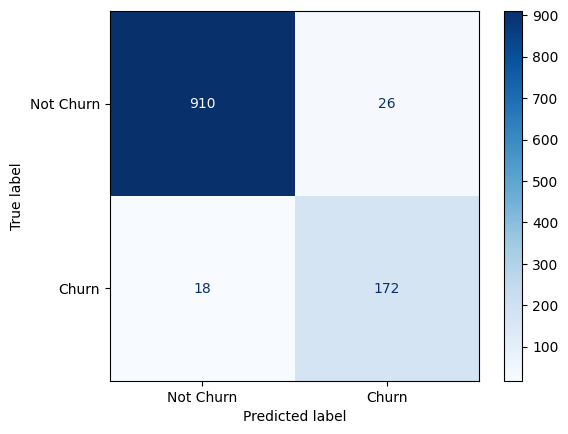

In [11]:
ConfusionMatrixDisplay.from_estimator(
    best_model_dt, X_test_ord, y_test,
    display_labels=['Not Churn', 'Churn'],
    cmap='Blues',
    values_format='d'
)

### Случайный лес

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=42)

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'max_features': range(2, 18, 2)
}

grid_search1 = GridSearchCV(rf, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search1.fit(X_train_ord, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_features': range(2, 18, 2), 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : t

In [13]:
best_model_rf = grid_search1.best_estimator_
y_pred = best_model_rf.predict(X_test_ord)

acc_rf = accuracy_score(y_test, y_pred)
prec_rf = precision_score(y_test, y_pred)
rec_rf = recall_score(y_test, y_pred)
f1_rf = f1_score(y_test, y_pred)

print(f"Лучшие параметры: {grid_search1.best_params_}")
print(f"Лучший score на валидации: {grid_search1.best_score_}\n")
print(f"Accuracy: {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall: {rec_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Лучшие параметры: {'max_depth': 15, 'max_features': 8, 'n_estimators': 150}
Лучший score на валидации: 0.8700656234225139

Accuracy: 0.9813
Precision: 0.9617
Recall: 0.9263
F1-score: 0.9437

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       936
           1       0.96      0.93      0.94       190

    accuracy                           0.98      1126
   macro avg       0.97      0.96      0.97      1126
weighted avg       0.98      0.98      0.98      1126



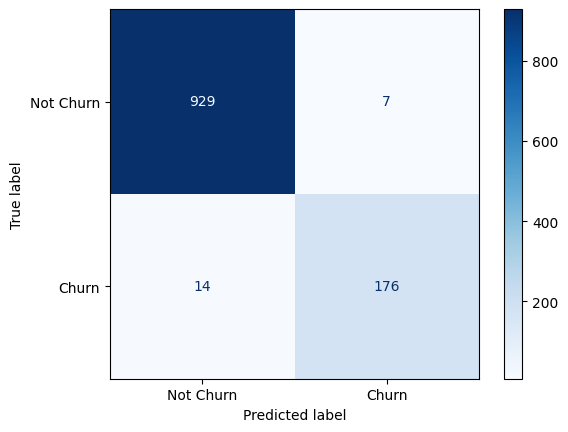

In [14]:
ConfusionMatrixDisplay.from_estimator(
    best_model_rf, X_test_ord, y_test,
    display_labels=['Not Churn', 'Churn'],
    cmap='Blues',
    values_format='d'
)

### Бустинг

Вычисление соотношения классов для scale_pos_weight

In [15]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f"Соотношение классов: {scale_pos_weight:.2f}")

Соотношение классов: 4.94


XGBoost

In [16]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb_params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}
xgb_clf = XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight)
xgb_grid = GridSearchCV(xgb_clf, xgb_params, cv=5, scoring='f1', n_jobs=-1)
xgb_grid.fit(X_train_ord, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...], 'reg_alpha': [0, 0.1, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and par

In [17]:
xgb_best = xgb_grid.best_estimator_
print("XGBoost best params:", xgb_grid.best_params_)
print("XGBoost best score:", xgb_grid.best_score_)

y_pred = xgb_best.predict(X_test_ord)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

XGBoost best params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 150, 'reg_alpha': 0.1, 'reg_lambda': 1}
XGBoost best score: 0.8854962536028115
Accuracy: 0.9911
Precision: 0.9688
Recall: 0.9789
F1-score: 0.9738

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99       936
           1       0.97      0.98      0.97       190

    accuracy                           0.99      1126
   macro avg       0.98      0.99      0.98      1126
weighted avg       0.99      0.99      0.99      1126



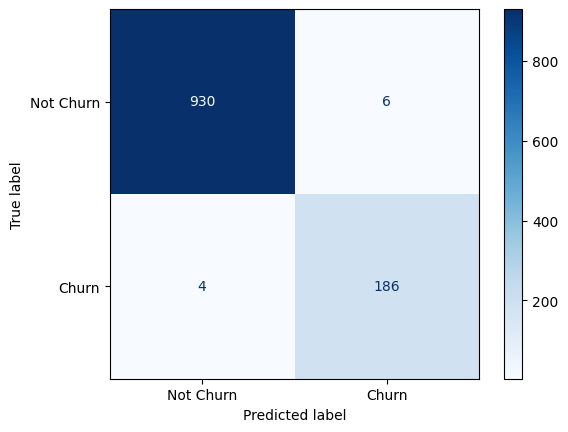

In [18]:
ConfusionMatrixDisplay.from_estimator(
    xgb_best, X_test_ord, y_test,
    display_labels=['Not Churn', 'Churn'],
    cmap='Blues',
    values_format='d'
)

### Leaf Model

In [19]:
from scripts.leaf_model import LeafModel
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

base_tree = DecisionTreeClassifier(max_leaf_nodes=5, random_state=42)
model_lr = LeafModel(tree=base_tree, leaf_model=LogisticRegression(max_iter=1000, random_state=42))

grid = GridSearchCV(model_lr, param_grid={'leaf_model__C': [0.1, 1.0, 10.0]}, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train_ohe, y_train)

llm_best = grid.best_estimator_
y_pred = llm_best.predict(X_test_ohe)
y_prob = llm_best.predict_proba(X_test_ohe)[:, 1]

print(f"✅ Best Params: {grid.best_params_}")
print(f"Acc: {accuracy_score(y_test, y_pred):.4f} | Prec: {precision_score(y_test, y_pred):.4f} | Rec: {recall_score(y_test, y_pred):.4f} | F1: {f1_score(y_test, y_pred):.4f} | ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred, zero_division=0))

✅ Best Params: {'leaf_model__C': 10.0}
Acc: 0.9094 | Prec: 0.8188 | Rec: 0.5947 | F1: 0.6890 | ROC-AUC: 0.9077
              precision    recall  f1-score   support

           0       0.92      0.97      0.95       936
           1       0.82      0.59      0.69       190

    accuracy                           0.91      1126
   macro avg       0.87      0.78      0.82      1126
weighted avg       0.90      0.91      0.90      1126



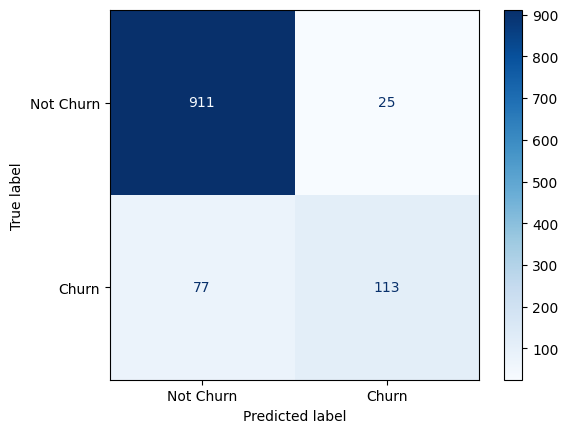

In [20]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Not Churn', 'Churn'],
    cmap='Blues',
    values_format='d'
)

In [21]:
from sklearn.ensemble import GradientBoostingClassifier

model_gb = LeafModel(leaf_model=GradientBoostingClassifier(random_state=42))

grid = GridSearchCV(model_gb, param_grid={
    'leaf_model__n_estimators': [50, 100, 150], 
    'leaf_model__max_depth': [3, 5, 7], 
    'leaf_model__learning_rate': [0.01, 0.1, 0.2]
}, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train_ord, y_train)

gb_lm_best = grid.best_estimator_
y_pred = gb_lm_best.predict(X_test_ord)
y_prob = gb_lm_best.predict_proba(X_test_ord)[:, 1]

print(f"✅ Best Params: {grid.best_params_}")
print(f"Acc: {accuracy_score(y_test, y_pred):.4f} | Prec: {precision_score(y_test, y_pred):.4f} | Rec: {recall_score(y_test, y_pred):.4f} | F1: {f1_score(y_test, y_pred):.4f} | ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred, zero_division=0))

✅ Best Params: {'leaf_model__learning_rate': 0.2, 'leaf_model__max_depth': 5, 'leaf_model__n_estimators': 100}
Acc: 0.9885 | Prec: 0.9683 | Rec: 0.9632 | F1: 0.9657 | ROC-AUC: 0.9984
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       936
           1       0.97      0.96      0.97       190

    accuracy                           0.99      1126
   macro avg       0.98      0.98      0.98      1126
weighted avg       0.99      0.99      0.99      1126



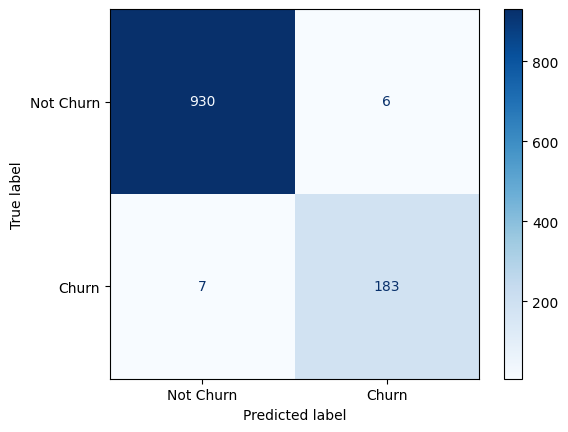

In [22]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Not Churn', 'Churn'],
    cmap='Blues',
    values_format='d'
)

### Нейронная сеть

In [23]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.utils.class_weight import compute_class_weight

# Создаем тензоры PyTorch
X_train_tensor = torch.FloatTensor(X_train_ohe.to_numpy())
X_test_tensor = torch.FloatTensor(X_test_ohe.to_numpy())
y_train_tensor = torch.LongTensor(y_train)
y_test_tensor = torch.LongTensor(y_test.values.astype(np.int64))

# Создаем DataLoader
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Нейронная сеть
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super(SimpleNN, self).__init__()
        layers = []
        prev_dim = input_dim
        
        for i, hidden_dim in enumerate(hidden_dims):
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.2))
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, output_dim))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)
    
    def predict_proba(self, X):
        self.eval()
        device = next(self.parameters()).device 
        
        with torch.no_grad():
            if hasattr(X, 'to_numpy'):
                X_np = X.to_numpy()
            else:
                X_np = np.array(X)
        
            X_tensor = torch.FloatTensor(X_np).to(device)
            outputs = self.forward(X_tensor)
            probs = F.softmax(outputs, dim=1)
            return probs.cpu().numpy()
    
    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)

print("=" * 60)
print("NEURAL NETWORK TRAINING")
print("=" * 60)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Инициализация модели
input_dim = X_train_tensor.shape[1]
model = SimpleNN(
    input_dim=input_dim,
    hidden_dims=[128, 64, 32],
    output_dim=2
).to(device)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Обучение
n_epochs = 50
for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    batch_count = 0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        batch_count += 1
    
    if (epoch + 1) % 10 == 0:
        avg_loss = total_loss / batch_count if batch_count > 0 else 0
        print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {avg_loss:.4f}")


print("\nMaking predictions...")

# Собираем предсказания
model.eval()
all_predictions = []
all_probs = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        outputs = model(batch_X)
        probs = F.softmax(outputs, dim=1)
        predictions = torch.argmax(outputs, dim=1)
        
        all_predictions.extend(predictions.cpu().tolist())
        all_probs.extend(probs[:, 1].cpu().tolist())
        all_labels.extend(batch_y.cpu().tolist())

# Преобразуем в numpy массивы
all_predictions_np = np.array(all_predictions)
all_probs_np = np.array(all_probs)
all_labels_np = np.array(all_labels)

print("\nCalculating metrics...")

accuracy_nn = accuracy_score(all_labels_np, all_predictions_np)
precision_nn = precision_score(all_labels_np, all_predictions_np)
recall_nn = recall_score(all_labels_np, all_predictions_np)
f1_nn = f1_score(all_labels_np, all_predictions_np)

print("\n" + "=" * 60)
print("NEURAL NETWORK RESULTS")
print("=" * 60)
print(f"Accuracy:  {accuracy_nn:.4f}")
print(f"Precision: {precision_nn:.4f}")
print(f"Recall:    {recall_nn:.4f}")
print(f"F1-Score:  {f1_nn:.4f}")

NEURAL NETWORK TRAINING
Epoch [10/50], Loss: 0.3048
Epoch [20/50], Loss: 0.2168
Epoch [30/50], Loss: 0.1725
Epoch [40/50], Loss: 0.1425
Epoch [50/50], Loss: 0.1267

Making predictions...

Calculating metrics...

NEURAL NETWORK RESULTS
Accuracy:  0.9387
Precision: 0.7336
Recall:    1.0000
F1-Score:  0.8463


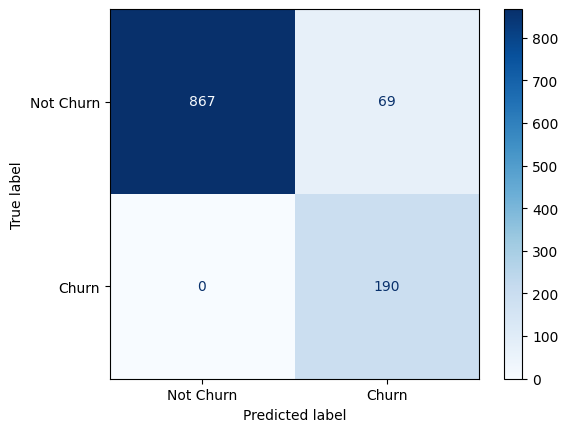

In [24]:
ConfusionMatrixDisplay.from_predictions(
    all_labels_np, all_predictions_np,
    display_labels=['Not Churn', 'Churn'],
    cmap='Blues',
    values_format='d'
)

In [25]:
from pytorch_tabnet.tab_model import TabNetClassifier

# Разделение на train/val
X_train_tb, X_val_tb, y_train_tb, y_val_tb = train_test_split(
    X_train_ord_sc, y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=42
)

# Веса классов — считаем на y_train_tb
y_train_np = np.asarray(y_train_tb).ravel()
class_counts = np.bincount(y_train_np)
sample_weights = np.where(
    y_train_np == 1,
    len(y_train_np) / (2 * class_counts[1]),
    len(y_train_np) / (2 * class_counts[0])
)

best_params = {
    'n_d': 64,
    'n_a': 32,
    'n_steps': 3,
    'gamma': 1.5,
    'mask_type': 'entmax',
    'lr': 0.01,
    'weight_decay': 1e-4,
    'batch_size': 512,
}

clf = TabNetClassifier(
    n_d=best_params['n_d'],
    n_a=best_params['n_a'],
    n_steps=best_params['n_steps'],
    gamma=best_params['gamma'],
    mask_type=best_params['mask_type'],
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=best_params['lr'], weight_decay=best_params['weight_decay']),
    verbose=1
)

clf.fit(
    X_train=X_train_tb.values, y_train=y_train_tb.values,
    eval_set=[(X_val_tb.values, y_val_tb.values)],
    eval_name=["val"],
    eval_metric=["auc"],
    max_epochs=100,
    patience=10,
    batch_size=best_params['batch_size'],
    virtual_batch_size=128,
    weights=sample_weights,
    drop_last=False
)

c:\Users\Nikita\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.86973 | val_auc: 0.59633 |  0:00:00s
epoch 1  | loss: 0.5174  | val_auc: 0.62782 |  0:00:00s
epoch 2  | loss: 0.44896 | val_auc: 0.75821 |  0:00:00s
epoch 3  | loss: 0.40329 | val_auc: 0.72125 |  0:00:00s
epoch 4  | loss: 0.33226 | val_auc: 0.78672 |  0:00:01s
epoch 5  | loss: 0.283   | val_auc: 0.78168 |  0:00:01s
epoch 6  | loss: 0.24514 | val_auc: 0.77532 |  0:00:01s
epoch 7  | loss: 0.23225 | val_auc: 0.78691 |  0:00:01s
epoch 8  | loss: 0.21176 | val_auc: 0.8223  |  0:00:01s
epoch 9  | loss: 0.17793 | val_auc: 0.83628 |  0:00:02s
epoch 10 | loss: 0.18108 | val_auc: 0.83288 |  0:00:02s
epoch 11 | loss: 0.18812 | val_auc: 0.84204 |  0:00:02s
epoch 12 | loss: 0.17314 | val_auc: 0.86195 |  0:00:02s
epoch 13 | loss: 0.187   | val_auc: 0.86372 |  0:00:03s
epoch 14 | loss: 0.14009 | val_auc: 0.87972 |  0:00:03s
epoch 15 | loss: 0.12    | val_auc: 0.88258 |  0:00:03s
epoch 16 | loss: 0.12686 | val_auc: 0.8983  |  0:00:03s
epoch 17 | loss: 0.13916 | val_auc: 0.90337 |  0

c:\Users\Nikita\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [26]:
y_val_proba = clf.predict_proba(X_val_tb.values)[:, 1]
best_thr, best_f1 = 0.5, 0
for thr in np.arange(0.1, 0.9, 0.02):
    f1_t = f1_score(y_val_tb, (y_val_proba > thr).astype(int), zero_division=0)
    if f1_t > best_f1:
        best_f1 = f1_t
        best_thr = thr

print(f"\nОптимальный порог: {best_thr:.2f} (val F1={best_f1:.4f})")

y_test_proba = clf.predict_proba(X_test_ord_sc.values)[:, 1]
y_test_pred = (y_test_proba > best_thr).astype(int)

print("\n" + "=" * 60)
print("ФИНАЛЬНЫЕ МЕТРИКИ НА ТЕСТЕ")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall: {recall_score(y_test,y_test_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_test_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))


Оптимальный порог: 0.84 (val F1=0.9114)

ФИНАЛЬНЫЕ МЕТРИКИ НА ТЕСТЕ
Accuracy: 0.9663
Precision: 0.8585
Recall: 0.9579
F1-score: 0.9055

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       936
           1       0.86      0.96      0.91       190

    accuracy                           0.97      1126
   macro avg       0.92      0.96      0.94      1126
weighted avg       0.97      0.97      0.97      1126



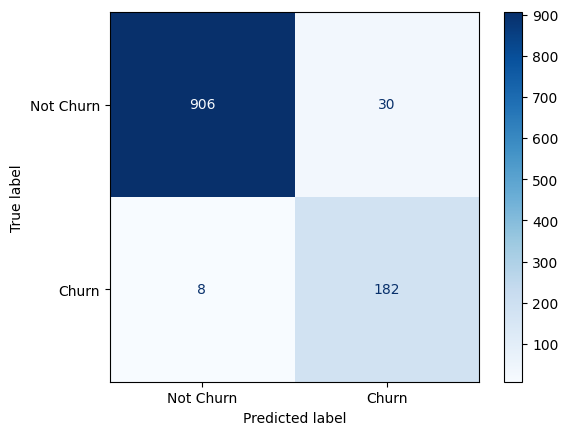

In [27]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=['Not Churn', 'Churn'],
    cmap='Blues',
    values_format='d'
)

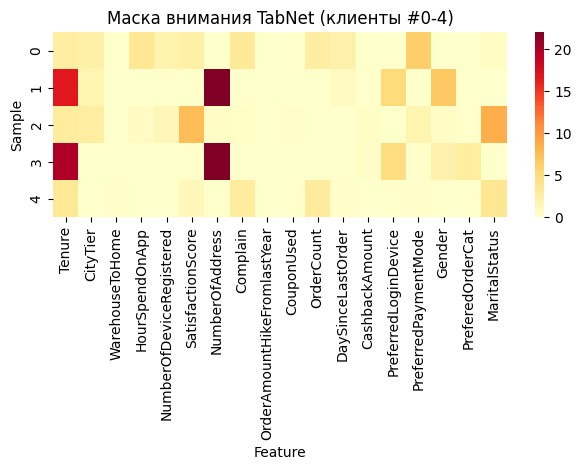

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

M_explain, M_loss = clf.explain(X_test_ord_sc.values[:5])

sns.heatmap(M_explain, xticklabels=X_test_ord_sc.columns, yticklabels=range(5), cmap="YlOrRd")
plt.title("Маска внимания TabNet (клиенты #0-4)")
plt.xlabel("Feature")
plt.ylabel("Sample")
plt.tight_layout()
plt.show()

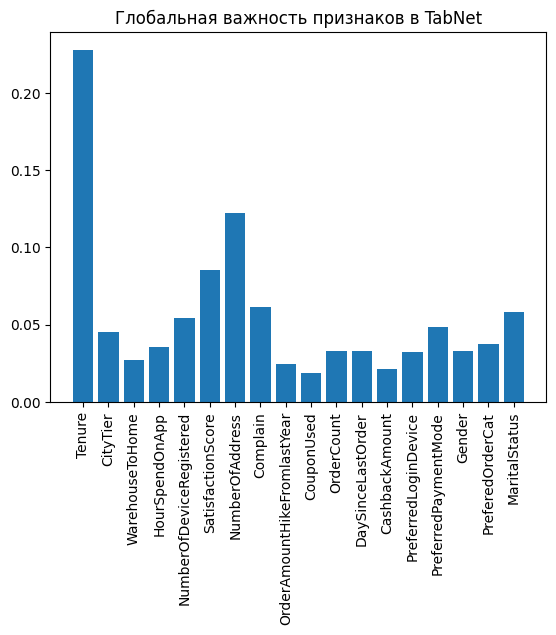

In [29]:
masks = []
preds = []
for x in X_test_ord_sc.values:
    explanation = clf.explain(x.reshape(1, -1))
    masks.append(explanation[0])
    preds.append(clf.predict(x.reshape(1, -1)))

masks = np.array(masks)
if masks.ndim == 3 and masks.shape[1] == 1:
    masks = masks.squeeze(1)

# Глобальная важность: среднее по всем сэмплам
global_importance = np.mean(masks, axis=0)
feature_names = X_test_ord_sc.columns.tolist()

# Нормализуем, чтобы сумма была 1
global_importance /= np.sum(global_importance)

plt.bar(range(len(feature_names)), global_importance)
plt.xticks(range(len(feature_names)), feature_names, rotation=90)
plt.title("Глобальная важность признаков в TabNet")
plt.show()

## Сравнение моделей

Модель                    |  ROC-AUC |   PR-AUC
---------------------------------------------
LogisticRegression        |   0.8734 |   0.6679
DecisionTree              |   0.9387 |   0.8950
RandomForest              |   0.9977 |   0.9891
XGBoost                   |   0.9993 |   0.9965
LogitLeafModel            |   0.9077 |   0.7713
GBLeafModel               |   0.9984 |   0.9895
MLP                       |   0.9942 |   0.9716
TabNet                    |   0.9930 |   0.9638


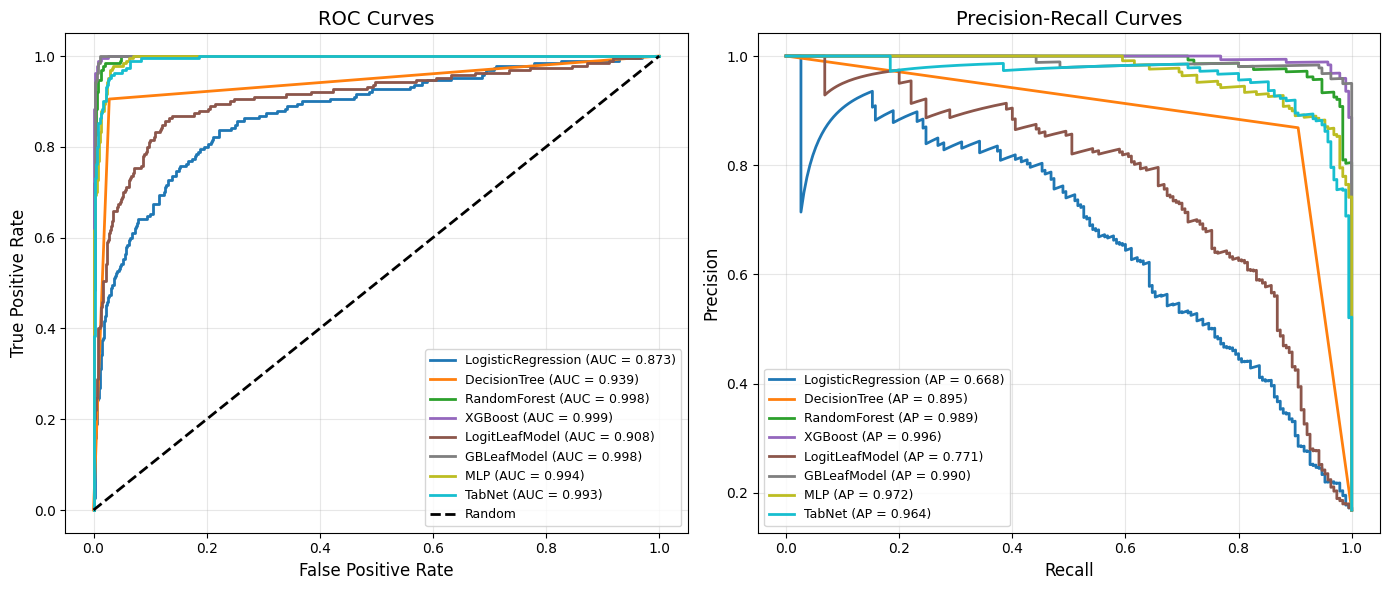

In [31]:
models = {
    'LogisticRegression': best_lr,
    'DecisionTree': best_model_dt,
    'RandomForest': best_model_rf,
    'XGBoost': xgb_best,
    'LogitLeafModel': llm_best,
    'GBLeafModel': gb_lm_best,
    'MLP': model,
    'TabNet': clf
}

# Тестовые данные для каждой модели
test_data = {
    'LogisticRegression': (X_test_ohe, y_test),
    'DecisionTree': (X_test_ord, y_test),
    'RandomForest': (X_test_ord, y_test),
    'XGBoost': (X_test_ord, y_test),
    'LogitLeafModel': (X_test_ohe, y_test),
    'GBLeafModel': (X_test_ord, y_test),
    'MLP': (X_test_ohe, y_test),
    'TabNet': (X_test_ord_sc, y_test)
}

roc_curves = {}
pr_curves = {}
auc_scores = {}
ap_scores = {}

for name, mdl in models.items():
    X_t, y_t = test_data[name]
    if name == 'TabNet':
        X_t = X_t.to_numpy()

    if hasattr(mdl, 'predict_proba'):
        y_score = mdl.predict_proba(X_t)[:, 1]
    else:
        y_score = mdl.predict(X_t)

    # ROC
    fpr, tpr, _ = roc_curve(y_t, y_score)
    roc_curves[name] = (fpr, tpr)
    auc_scores[name] = auc(fpr, tpr)

    # Precision-Recall
    precision, recall, _ = precision_recall_curve(y_t, y_score)
    pr_curves[name] = (precision, recall)
    ap_scores[name] = auc(recall, precision)

# Таблица метрик
print(f"{'Модель':<25} | {'ROC-AUC':>8} | {'PR-AUC':>8}")
print("-" * 45)
for name in models:
    print(f"{name:<25} | {auc_scores[name]:>8.4f} | {ap_scores[name]:>8.4f}")

# Графики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

# ROC
for i, (name, (fpr, tpr)) in enumerate(roc_curves.items()):
    ax1.plot(fpr, tpr, color=colors[i], linewidth=2,
             label=f'{name} (AUC = {auc_scores[name]:.3f})')

ax1.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curves', fontsize=14)
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, alpha=0.3)

# PR
for i, (name, (precision, recall)) in enumerate(pr_curves.items()):
    ax2.plot(recall, precision, color=colors[i], linewidth=2,
             label=f'{name} (AP = {ap_scores[name]:.3f})')

ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curves', fontsize=14)
ax2.legend(loc='lower left', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Интерпретация

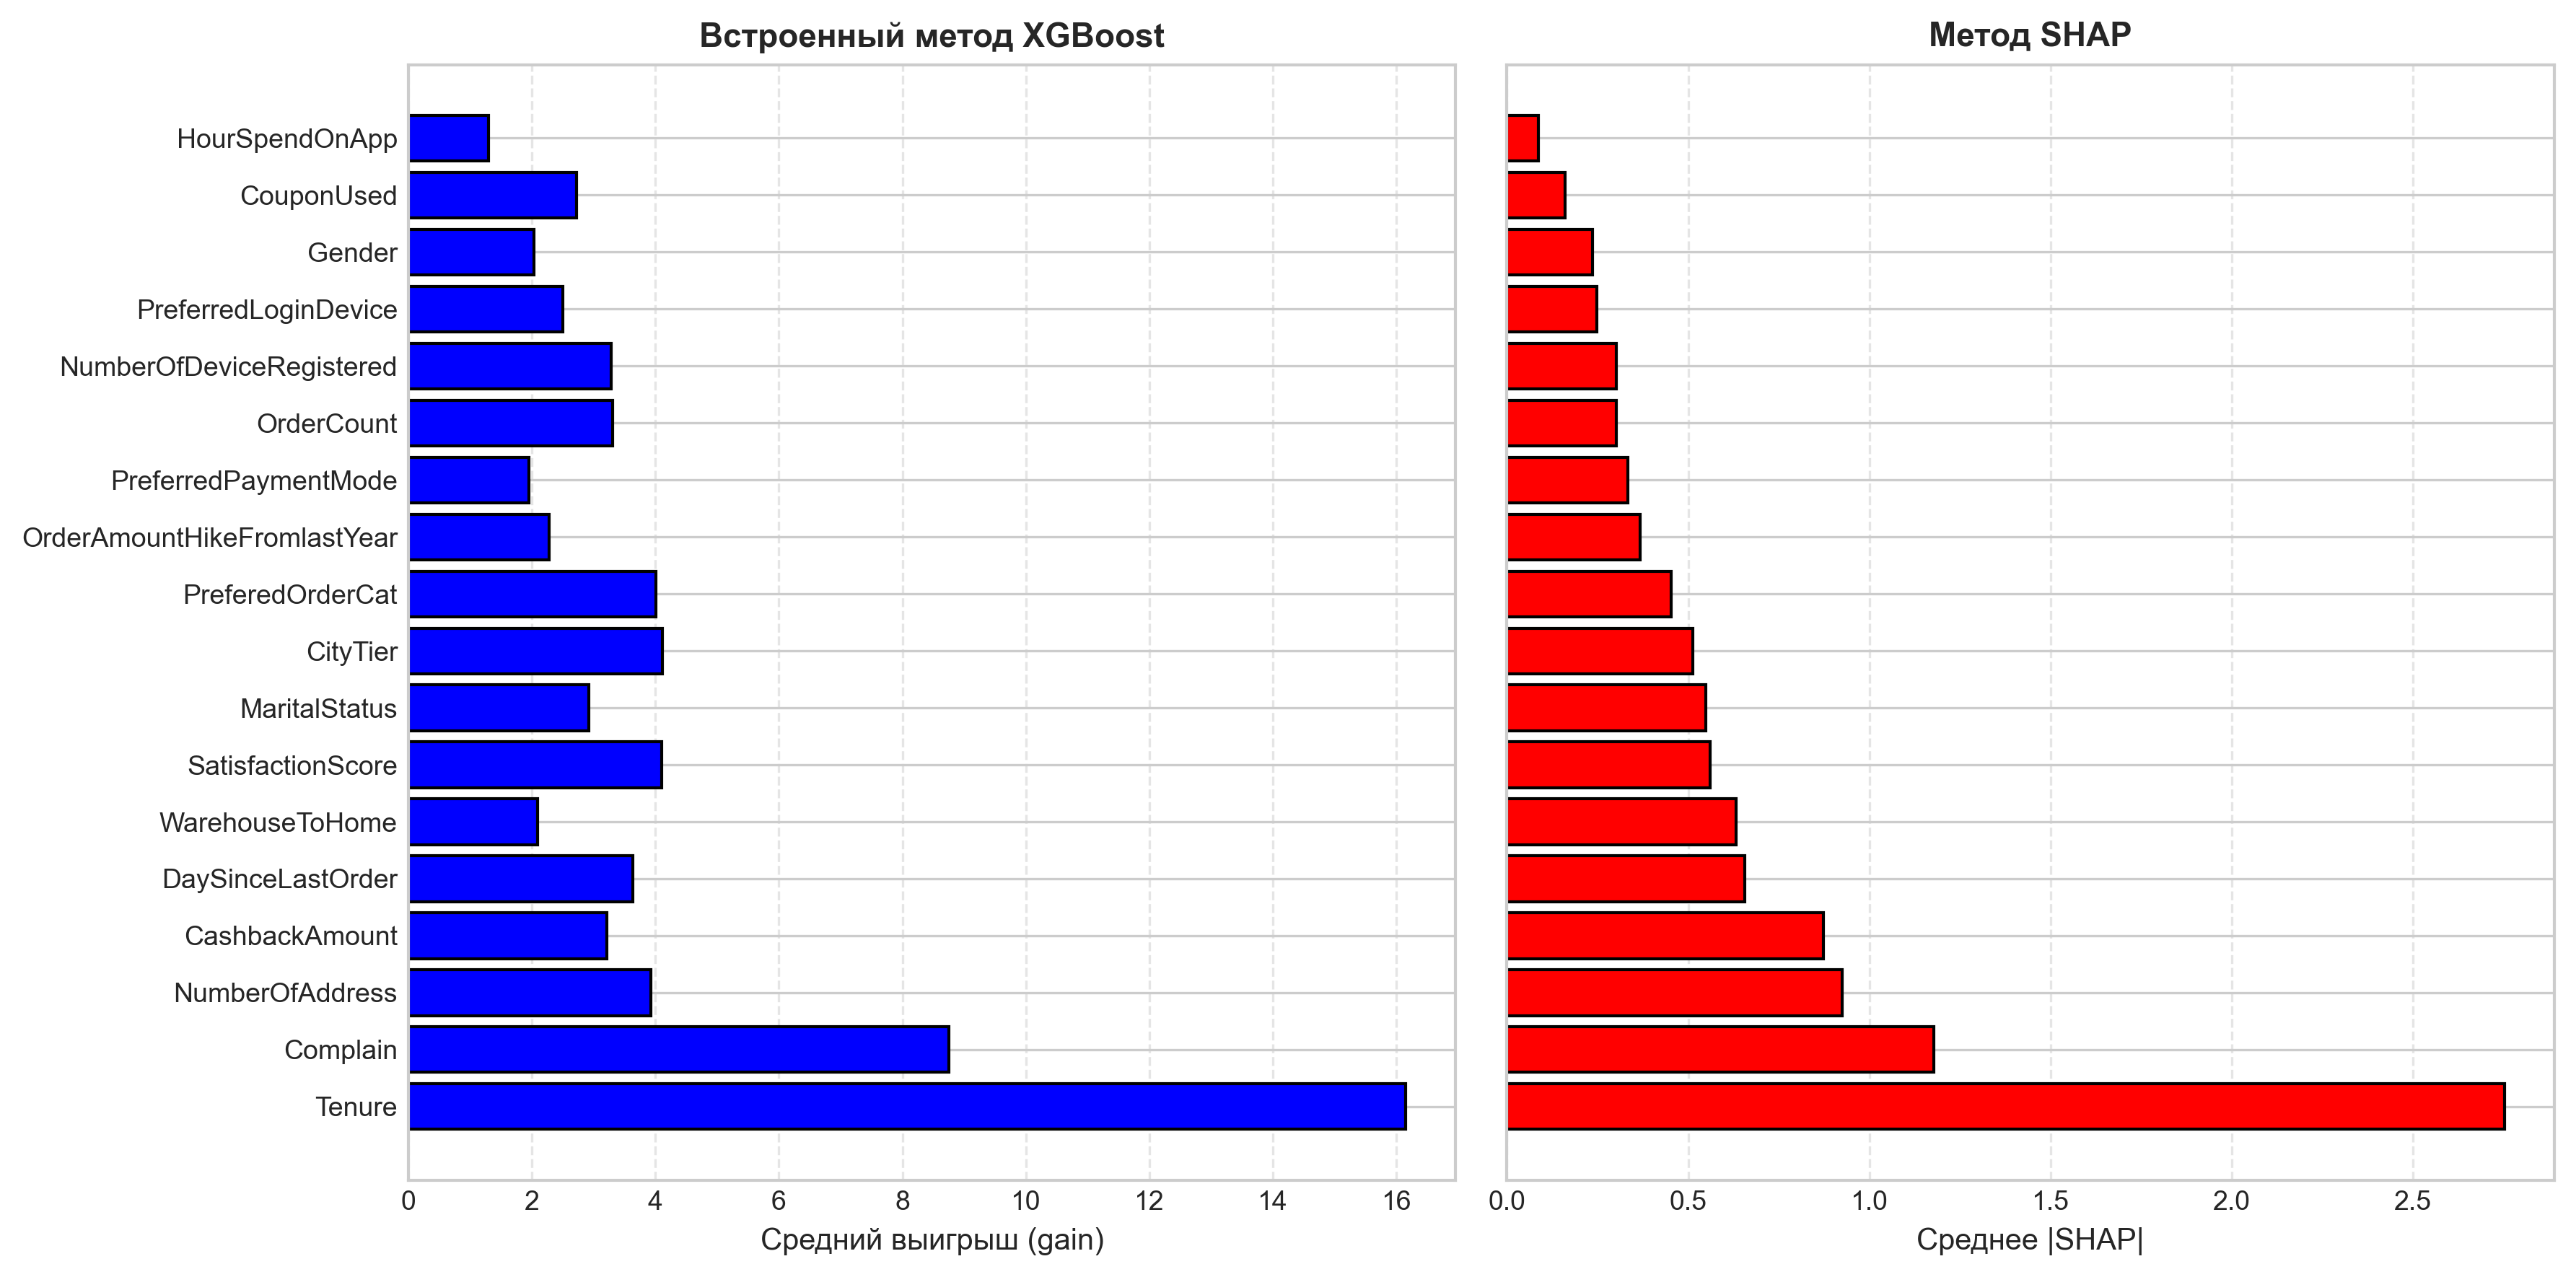

In [32]:
import matplotlib.pyplot as plt
import xgboost as xgb
import shap

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

feature_names = xgb_best.feature_names_in_

# Встроенная важность (Gain)
booster = xgb_best.get_booster()
importance_dict = booster.get_score(importance_type='gain')

importance_gain = pd.Series({
    feature_names[int(k[1:])] if k.startswith('f') else k: v 
    for k, v in importance_dict.items()
})
# Добавляем признаки с нулевой важностью (если они не попали в деревья)
importance_gain = importance_gain.reindex(feature_names, fill_value=0)

# SHAP глобальная важность
explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test_ord)

# Корректная обработка вывода для бинарной классификации
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # Класс 1 = отток
elif isinstance(shap_values, shap.Explanation):
    shap_values = shap_values.values

shap_importance = np.mean(np.abs(shap_values), axis=0)
shap_importance_series = pd.Series(shap_importance, index=feature_names)

top_n = 18
ordered_features = shap_importance_series.sort_values(ascending=False).head(top_n).index
importance_gain_plot = importance_gain.loc[ordered_features]
shap_importance_plot = shap_importance_series.loc[ordered_features]

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
y_labels = [f.replace('_', ' ') for f in ordered_features]

# Левый график: Встроенный метод (СИНИЙ)
axes[0].barh(range(len(ordered_features)), importance_gain_plot.values, 
             color='blue', edgecolor='black')
axes[0].set_yticks(range(len(ordered_features)))
axes[0].set_yticklabels(y_labels, fontsize=9)
axes[0].set_xlabel('Средний выигрыш (gain)', fontsize=10)
axes[0].set_title('Встроенный метод XGBoost', fontsize=11, fontweight='bold')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)
axes[0].invert_yaxis()

# Правый график: SHAP (КРАСНЫЙ)
axes[1].barh(range(len(ordered_features)), shap_importance_plot.values, 
             color='red', edgecolor='black')
axes[1].set_xlabel('Среднее |SHAP|', fontsize=10)
axes[1].set_title('Метод SHAP', fontsize=11, fontweight='bold')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)
axes[1].invert_yaxis()
axes[1].tick_params(left=False, labelleft=False)

plt.tight_layout()
plt.show()

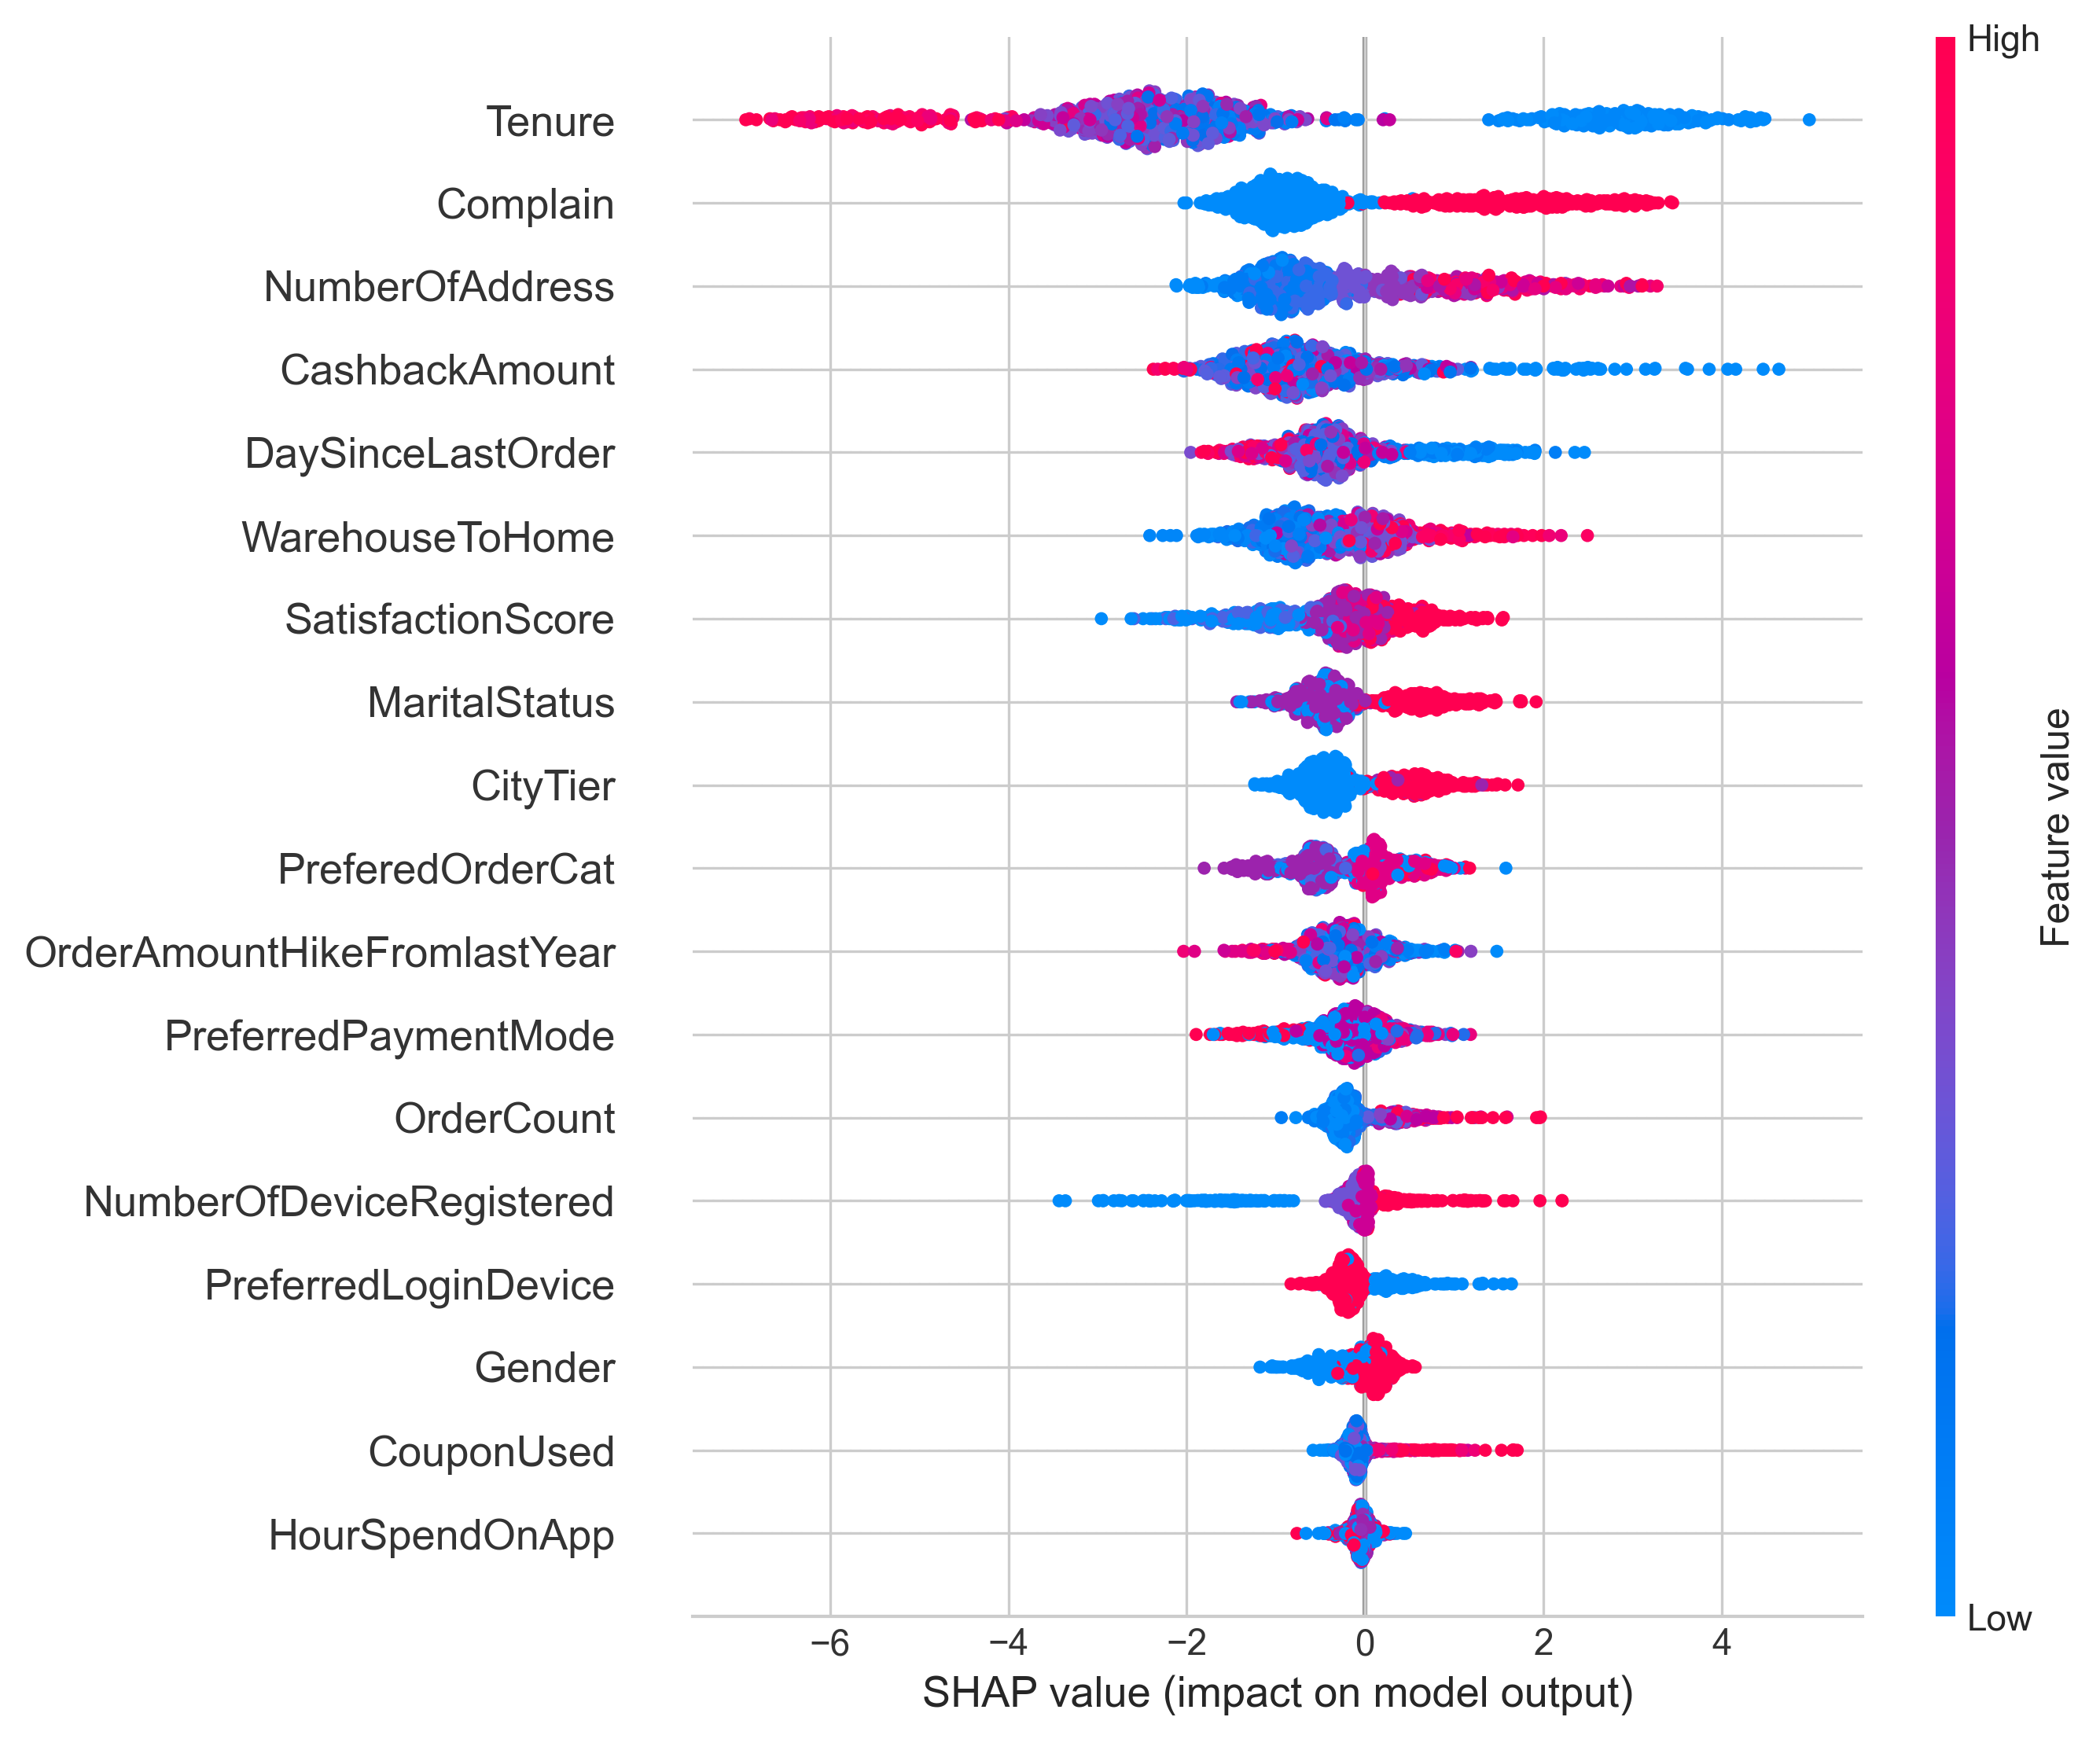

In [33]:
explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer(X_test_ord)
shap.plots.beeswarm(shap_values, max_display=20)

Катекориальные признаки: PreferredLoginDevice, CityTier, PreferredPaymentMode, Gender, PreferedOrderCat, MaritalStatus, Complain

Вычисление локальных SHAP-значений...
Вычисление локальных LIME-значений...


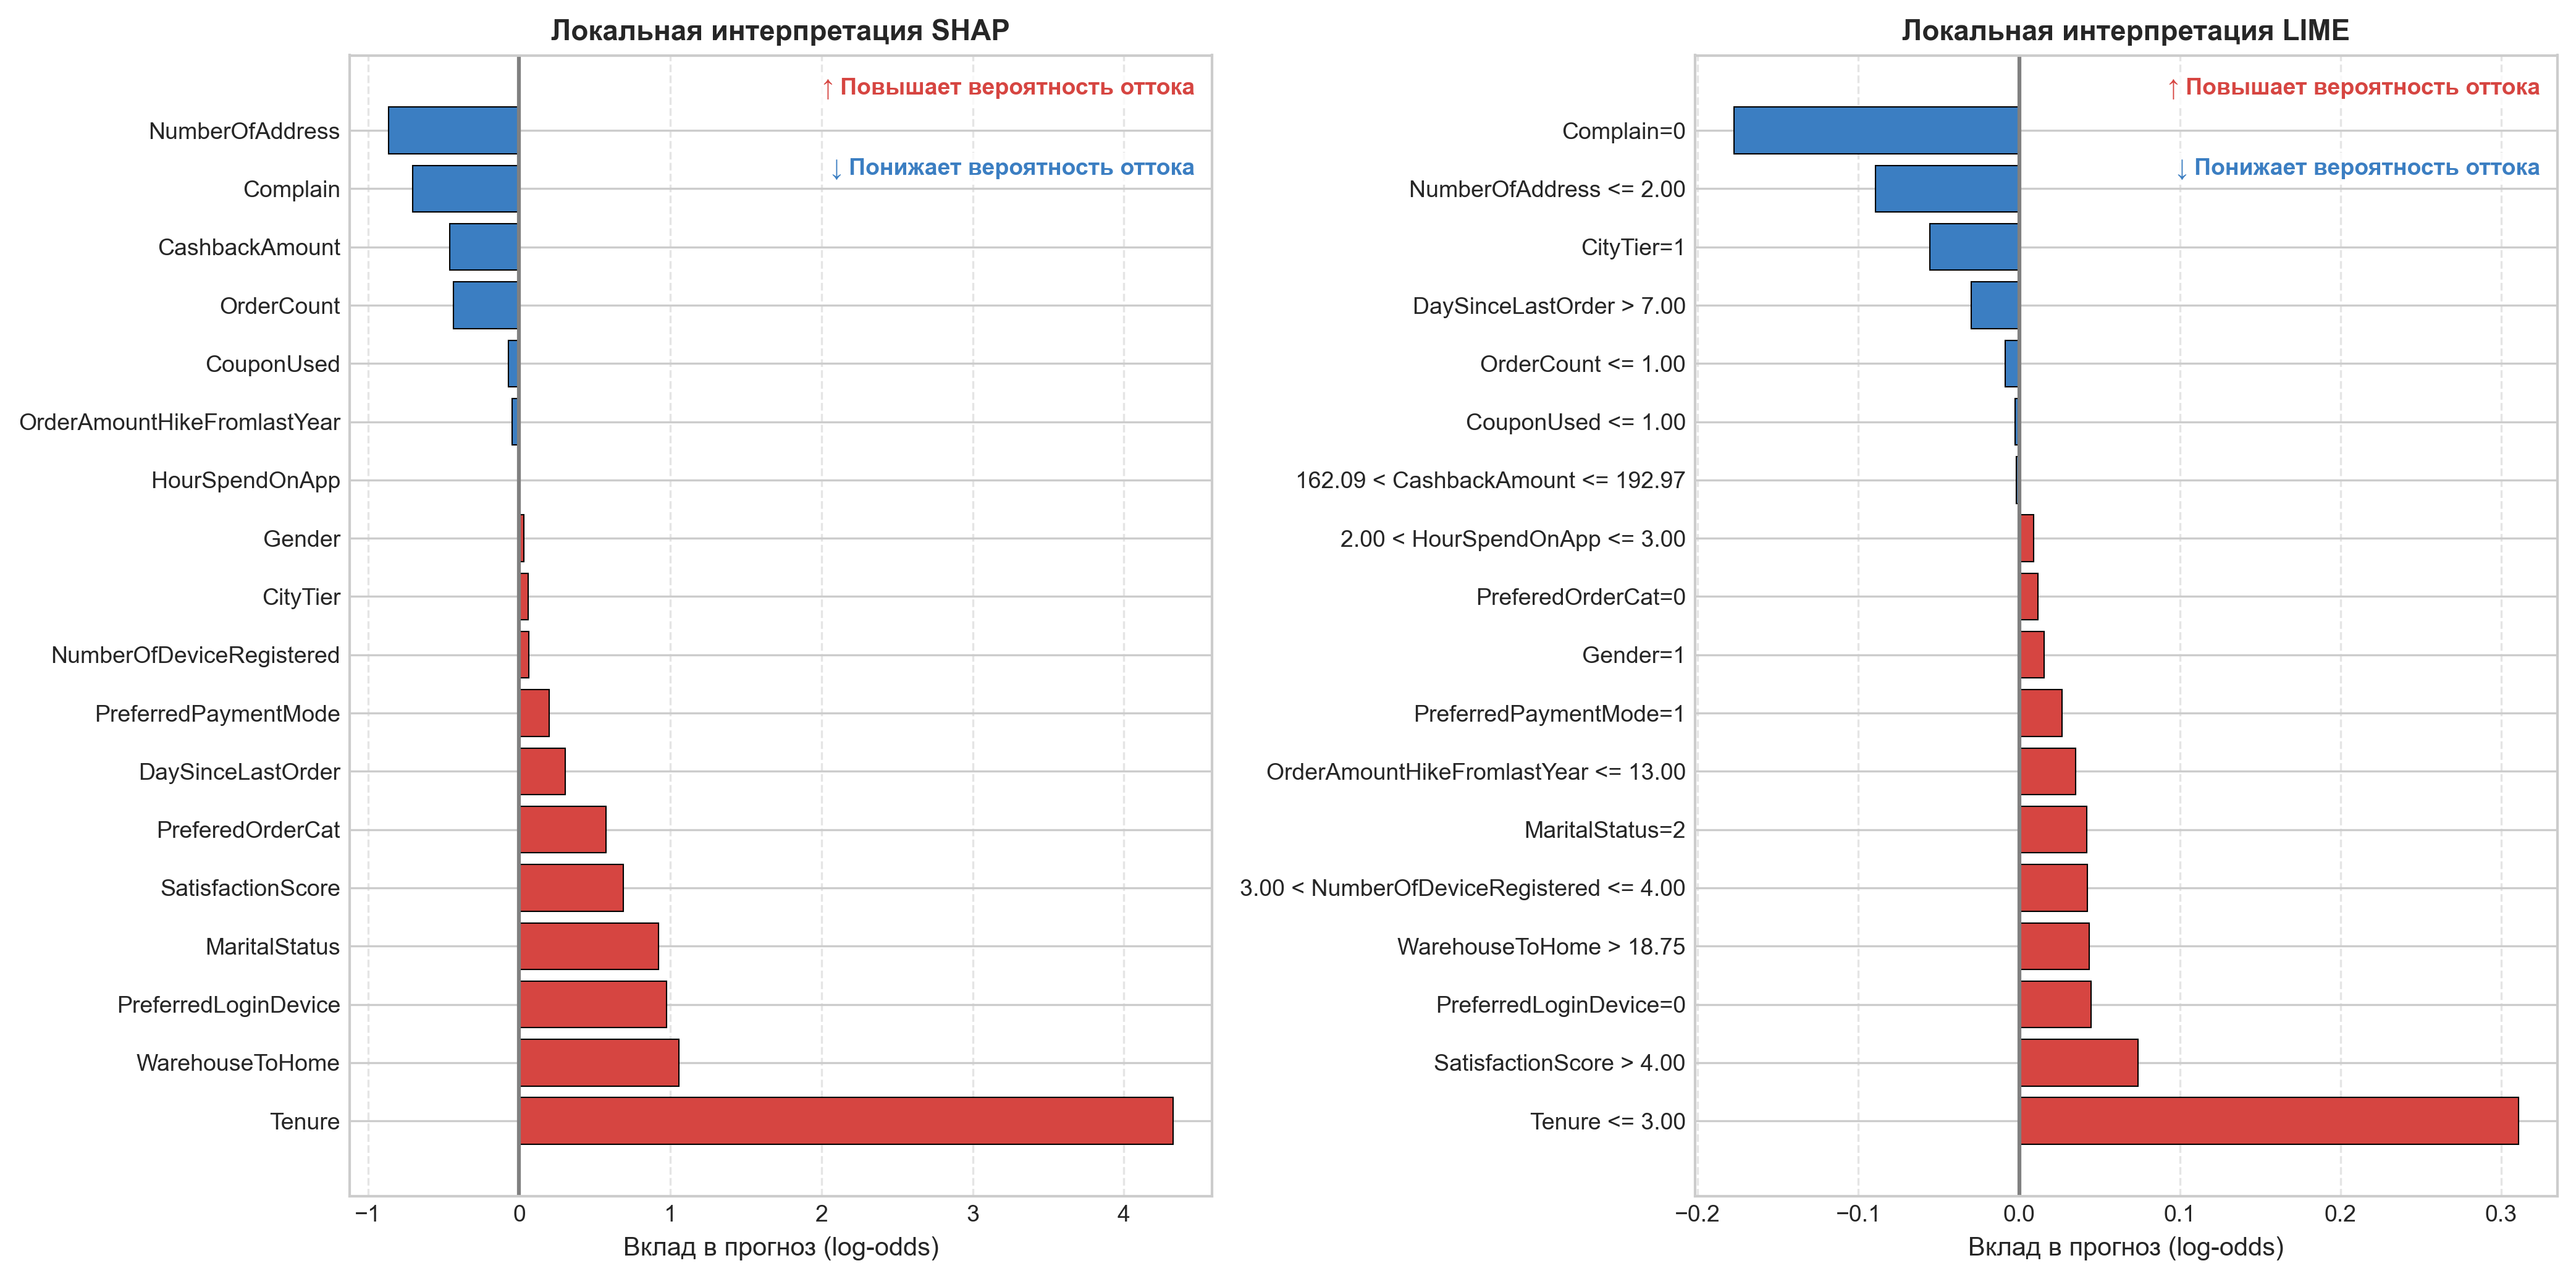

In [34]:
import lime
import lime.lime_tabular

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

if 'y_test' in locals():
    idx_candidates = np.where(np.array(y_test) == 1)[0]
    idx = idx_candidates[0] if len(idx_candidates) > 0 else 0
else:
    idx = 0

feature_names = X_test_ord.columns.tolist()

print("Вычисление локальных SHAP-значений...")
explainer_shap = shap.TreeExplainer(xgb_best)
shap_values_full = explainer_shap.shap_values(X_test_ord.iloc[idx:idx+1])

# Универсальная обработка вывода SHAP для разных версий библиотеки
if isinstance(shap_values_full, list):
    shap_vals = shap_values_full[1][0]  # Класс 1, первое наблюдение
elif isinstance(shap_values_full, shap.Explanation):
    shap_vals = shap_values_full.values[0]
else:
    shap_vals = shap_values_full[0]

shap_df = pd.DataFrame({'Feature': feature_names, 'Value': shap_vals})
shap_df = shap_df.reindex(shap_df['Value'].abs().sort_values(ascending=False).index).head(18)

print("Вычисление локальных LIME-значений...")
# Список категориальных признаков
cat_feature_names = ['PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode', 
                     'Gender', 'PreferedOrderCat', 'MaritalStatus', 'Complain']

# Динамически находим их индексы в DataFrame
cat_indices = [feature_names.index(c) for c in cat_feature_names if c in feature_names]

# LIME требует numpy.ndarray для внутренних вычислений
training_data_np = X_test_ord.values
instance_np = X_test_ord.iloc[idx].values

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=training_data_np,
    feature_names=feature_names,
    categorical_features=cat_indices,
    class_names=['No Churn', 'Churn'],
    mode='classification',
    random_state=42
)

exp = explainer_lime.explain_instance(
    instance_np, 
    xgb_best.predict_proba, 
    num_features=18,
    labels=[1]
)

lime_data = exp.as_list(label=1)
lime_df = pd.DataFrame(lime_data, columns=['Feature', 'Value'])
lime_df = lime_df.reindex(lime_df['Value'].abs().sort_values(ascending=False).index)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=False)

def plot_local_bars(ax, df, title_text, pos_color, neg_color):
    df_plot = df.copy()
    df_plot['Feature'] = df_plot['Feature'].apply(lambda x: x.replace('_', ' '))
    df_plot = df_plot.sort_values(by='Value', ascending=True)
    
    y_pos = range(len(df_plot))
    colors = [pos_color if v > 0 else neg_color for v in df_plot['Value']]
    
    ax.barh(y_pos, df_plot['Value'], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_plot['Feature'], fontsize=9)
    ax.set_xlabel('Вклад в прогноз (log-odds)', fontsize=10)
    ax.set_title(title_text, fontsize=11, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.axvline(x=0, color='gray', linewidth=1.5)
    ax.invert_yaxis()
    
    # Легенда в верхнем правом углу с полупрозрачным фоном для читаемости
    ax.text(0.98, 0.98, '↑ Повышает вероятность оттока', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color=pos_color, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=2))
    ax.text(0.98, 0.91, '↓ Понижает вероятность оттока', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color=neg_color, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=2))

plot_local_bars(axes[0], shap_df, 'Локальная интерпретация SHAP', '#d64541', '#3b7ec2')
plot_local_bars(axes[1], lime_df, 'Локальная интерпретация LIME', '#d64541', '#3b7ec2')

plt.tight_layout()
plt.show()